# 01 - Data Preprocessing

Generates a grid of San Diego locations, computes environmental features for each,
and creates a composite safety score as the prediction target.

### Inputs
- `data/raw/crime_2023.csv` - SDPD calls for service
- `data/raw/walkability.csv` - EPA National Walkability Index
- `data/raw/census_bg/` - Census TIGER block group boundaries
- `data/raw/streetlights.geojson` - SD streetlight locations

### Output
- `data/processed/modeling_df.csv` - grid of SD locations with features + safety label

In [111]:
import pandas as pd
import geopandas as gpd
import numpy as np
from shapely.geometry import Point
from pathlib import Path
from tqdm import tqdm

RAW = Path('../data/raw')
PROCESSED = Path('../data/processed')
PROCESSED.mkdir(exist_ok=True)
print('Libraries loaded!')

Libraries loaded!


## 1. Generate San Diego Location Grid

In [112]:
LAT_MIN, LAT_MAX = 32.55, 33.10
LON_MIN, LON_MAX = -117.28, -116.93
LAT_STEP = 0.0045
LON_STEP = 0.0055

lats = np.arange(LAT_MIN, LAT_MAX, LAT_STEP)
lons = np.arange(LON_MIN, LON_MAX, LON_STEP)
grid_points = [(lat, lon) for lat in lats for lon in lons]
grid_df = pd.DataFrame(grid_points, columns=['lat', 'lon'])
grid_df['location_id'] = [f'sd_{i}' for i in range(len(grid_df))]

grid_gdf = gpd.GeoDataFrame(
    grid_df,
    geometry=gpd.points_from_xy(grid_df['lon'], grid_df['lat']),
    crs='EPSG:4326'
)
print(f'Grid points: {len(grid_gdf)}')
grid_gdf.head(3)

Grid points: 7872


,lat,lon,location_id,geometry
0,32.55,-117.2800,sd_0,POINT (-117.28 32.55)
1,32.55,-117.2745,sd_1,POINT (-117.2745 32.55)
2,32.55,-117.2690,sd_2,POINT (-117.269 32.55)


## 2. Load & Process Crime Data

In [113]:
crime = pd.read_csv(RAW / 'crime_2024.csv', low_memory=False)
print('Crime shape:', crime.shape)
crime_by_beat = crime.groupby('BEAT').size().reset_index(name='crime_count')
crime_by_beat['crime_density_norm'] = (
    crime_by_beat['crime_count'] - crime_by_beat['crime_count'].min()
) / (crime_by_beat['crime_count'].max() - crime_by_beat['crime_count'].min())
crime_by_beat['crime_score'] = 1 - crime_by_beat['crime_density_norm']
print('Beats:', len(crime_by_beat))
crime_by_beat.head()

Crime shape: (970650, 14)
Beats: 129


,BEAT,crime_count,crime_density_norm,crime_score
0,-1,17362,0.293950,0.706050
1,0,8,0.000034,0.999966
2,9,6,0.000000,1.000000
3,111,10794,0.182711,0.817289
4,112,3476,0.058770,0.941230


## 3. Load Walkability + Census Block Groups

In [114]:
walk = pd.read_csv(RAW / 'walkability.csv', low_memory=False)

walk_sd_fixed = walk[walk['COUNTYFP'] == 73].copy()
walk_sd_fixed['GEOID_fixed'] = (
    '06' +
    walk_sd_fixed['COUNTYFP'].astype(str).str.zfill(3) +
    walk_sd_fixed['TRACTCE'].astype(str).str.zfill(6) +
    walk_sd_fixed['BLKGRPCE'].astype(str).str.zfill(1)
)
walk_sd_fixed['walk_score'] = (
    walk_sd_fixed['NatWalkInd'] - walk_sd_fixed['NatWalkInd'].min()
) / (walk_sd_fixed['NatWalkInd'].max() - walk_sd_fixed['NatWalkInd'].min())

print(f'SD block groups: {len(walk_sd_fixed)}')
print(walk_sd_fixed[['GEOID_fixed', 'NatWalkInd', 'walk_score']].head(3))

SD block groups: 3443
       GEOID_fixed  NatWalkInd  walk_score
4633  060739505002    9.000000    0.428571
4634  060739506002    6.500000    0.294643
5333  060739508022    2.833333    0.098214


In [115]:
shp_files = list((RAW / 'census_bg').glob('*.shp'))
print('Shapefiles found:', shp_files)
census = gpd.read_file(shp_files[0])
census_sd = census[census['COUNTYFP'] == '073'].copy()
census_sd = census_sd.to_crs('EPSG:4326')
census_sd['GEOID'] = census_sd['GEOID'].astype(str)
census_walk = census_sd.merge(walk_sd_fixed, left_on='GEOID', right_on='GEOID_fixed', how='left')
print('Census+walk shape:', census_walk.shape)
print('Missing walk scores:', census_walk['walk_score'].isna().sum())

Shapefiles found: [PosixPath('../data/raw/census_bg/tl_2020_06_bg.shp')]
Census+walk shape: (2321, 132)
Missing walk scores: 558


## 4. Load Streetlights

In [116]:
import requests
import warnings
from shapely.geometry import shape
warnings.filterwarnings('ignore')

# Check if full streetlights already downloaded
full_path = RAW / 'streetlights_full.geojson'
if full_path.exists():
    lights = gpd.read_file(full_path)
    print(f'Loaded from cache: {lights.shape}')
else:
    # Paginate through ArcGIS REST API
    all_features = []
    offset = 0
    batch_size = 1000
    while True:
        url = (
            f"https://webmaps.sandiego.gov/arcgis/rest/services/Planning/PLN_Mobility/MapServer/1/query"
            f"?where=1%3D1&outFields=OBJECTID,STATUS,SHAPE&f=geojson"
            f"&resultOffset={offset}&resultRecordCount={batch_size}"
        )
        r = requests.get(url, verify=False)
        data = r.json()
        features = data.get('features', [])
        if not features:
            break
        all_features.extend(features)
        offset += batch_size
        print(f'Fetched {len(all_features)} so far...')
        if len(features) < batch_size:
            break

    geoms = [shape(f['geometry']) for f in all_features]
    lights = gpd.GeoDataFrame(
        [f['properties'] for f in all_features],
        geometry=geoms,
        crs='EPSG:4326'
    )
    lights.to_file(full_path, driver='GeoJSON')
    print(f'Fetched and saved: {lights.shape}')

lights = lights.to_crs('EPSG:4326')
print(f'Streetlights ready: {lights.shape}')

Loaded from cache: (56058, 3)
Streetlights ready: (56058, 3)


## 5. Spatial Join - Assign Walk Score to Grid Points

In [117]:
grid_walk = gpd.sjoin(
    grid_gdf,
    census_walk[['geometry', 'walk_score', 'NatWalkInd']],
    how='left',
    predicate='within'
)
grid_walk = grid_walk.drop_duplicates(subset='location_id')
print('After walk join:', grid_walk.shape)
print('Missing walk scores:', grid_walk['walk_score'].isna().sum())
grid_walk[['location_id', 'lat', 'lon', 'walk_score']].head(3)

After walk join: (7872, 7)
Missing walk scores: 2605


,location_id,lat,lon,walk_score
0,sd_0,32.55,-117.2800,NaN
1,sd_1,32.55,-117.2745,NaN
2,sd_2,32.55,-117.2690,NaN


## 6. Compute Lighting Score (streetlights within 200m)

In [118]:
grid_proj = grid_walk.to_crs('EPSG:32611')
lights_proj = lights.to_crs('EPSG:32611')
lights_geom = lights_proj.geometry

light_counts = []
for geom in tqdm(grid_proj.geometry, desc='Computing light density'):
    buf = geom.buffer(200)
    light_counts.append(lights_geom.within(buf).sum())

grid_walk = grid_walk.copy()
grid_walk['light_count'] = light_counts
grid_walk['light_score'] = (
    grid_walk['light_count'] - grid_walk['light_count'].min()
) / (grid_walk['light_count'].max() - grid_walk['light_count'].min())
print('Light score stats:')
print(grid_walk['light_score'].describe())

Computing light density: 100%|██████████| 7872/7872 [00:11<00:00, 706.52it/s]

Light score stats:
count    7872.000000
mean        0.018995
std         0.052207
min         0.000000
25%         0.000000
50%         0.000000
75%         0.011111
max         1.000000
Name: light_score, dtype: float64


## 7. Assign Crime Score

In [119]:
median_crime_score = crime_by_beat['crime_score'].median()
grid_walk['crime_score'] = median_crime_score
print(f'Assigned median crime score: {median_crime_score:.3f}')

Assigned median crime score: 0.908


## 8. Compute Composite Safety Score (Target Variable)

In [120]:
grid_walk['walk_score'] = grid_walk['walk_score'].fillna(grid_walk['walk_score'].median())

grid_walk['safety_score'] = (
    0.50 * grid_walk['crime_score'] +
    0.25 * grid_walk['walk_score'] +
    0.25 * grid_walk['light_score']
)

threshold = grid_walk['safety_score'].median()
grid_walk['safe_label'] = (grid_walk['safety_score'] >= threshold).astype(int)

print('Safety score stats:')
print(grid_walk['safety_score'].describe())
print('\nClass balance:')
print(grid_walk['safe_label'].value_counts())

Safety score stats:
count    7872.000000
mean        0.556839
std         0.056393
min         0.453983
25%         0.529876
50%         0.545501
75%         0.595080
max         0.804182
Name: safety_score, dtype: float64

Class balance:
safe_label
1    5379
0    2493
Name: count, dtype: int64


## 9. Save Modeling DataFrame

In [121]:
modeling_df = grid_walk[[
    'location_id', 'lat', 'lon',
    'crime_score', 'walk_score', 'NatWalkInd',
    'light_count', 'light_score',
    'safety_score', 'safe_label'
]].copy()
modeling_df = modeling_df.dropna(subset=['walk_score'])
modeling_df.to_csv(PROCESSED / 'modeling_df.csv', index=False)
print(f'Saved! Shape: {modeling_df.shape}')
modeling_df.describe()

Saved! Shape: (7872, 10)


,lat,lon,crime_score,walk_score,NatWalkInd,light_count,light_score,safety_score,safe_label
count,7872.000000,7872.000000,7.872000e+03,7872.000000,5267.000000,7872.000000,7872.000000,7872.000000,7872.000000
mean,32.824500,-117.106750,9.079669e-01,0.392426,8.568603,3.419080,0.018995,0.556839,0.683308
std,0.159787,0.101608,4.441174e-16,0.208865,4.747765,9.397275,0.052207,0.056393,0.465216
min,32.550000,-117.280000,9.079669e-01,0.000000,1.000000,0.000000,0.000000,0.453983,0.000000
25%,32.685000,-117.193375,9.079669e-01,0.303571,5.333333,0.000000,0.000000,0.529876,0.000000
50%,32.824500,-117.106750,9.079669e-01,0.366071,7.833333,0.000000,0.000000,0.545501,1.000000
75%,32.964000,-117.020125,9.079669e-01,0.526786,12.500000,2.000000,0.011111,0.595080,1.000000
max,33.099000,-116.933500,9.079669e-01,1.000000,19.666667,180.000000,1.000000,0.804182,1.000000


## 10. EDA Plots

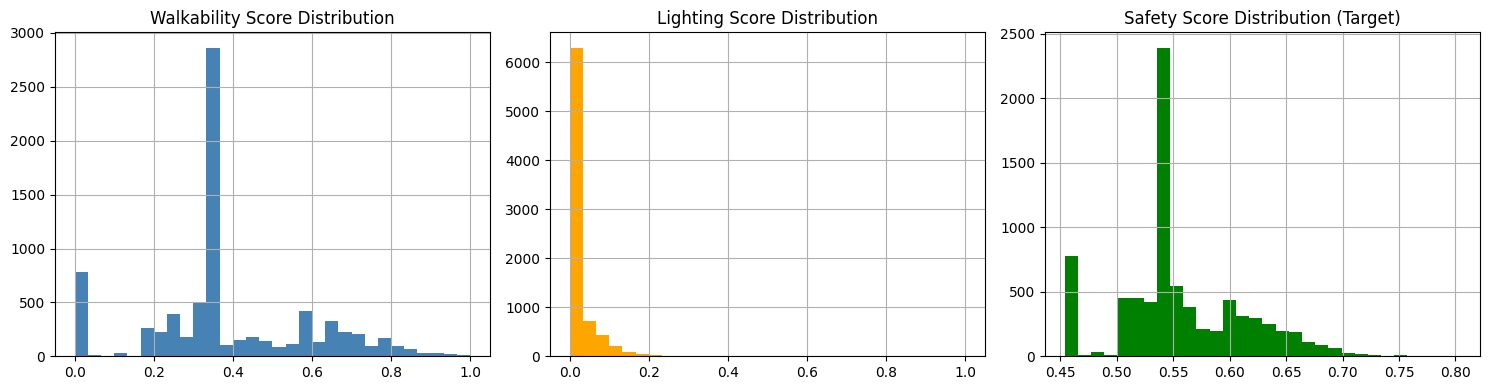

EDA plot saved!


In [122]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
modeling_df['walk_score'].hist(ax=axes[0], bins=30, color='steelblue')
axes[0].set_title('Walkability Score Distribution')
modeling_df['light_score'].hist(ax=axes[1], bins=30, color='orange')
axes[1].set_title('Lighting Score Distribution')
modeling_df['safety_score'].hist(ax=axes[2], bins=30, color='green')
axes[2].set_title('Safety Score Distribution (Target)')
plt.tight_layout()
plt.savefig(PROCESSED / 'eda_distributions.png', dpi=150)
plt.show()
print('EDA plot saved!')

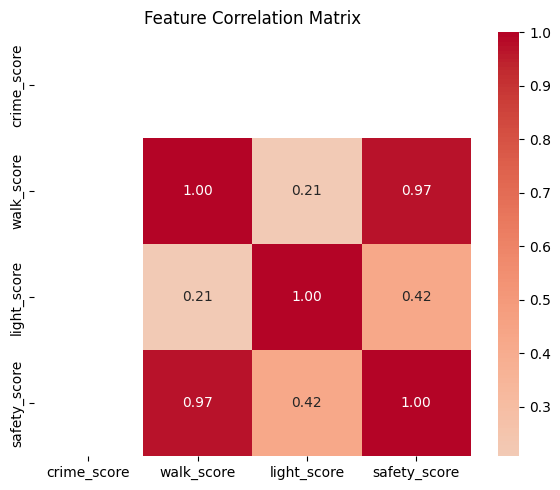

Correlation matrix saved!


In [123]:
corr_cols = ['crime_score', 'walk_score', 'light_score', 'safety_score']
corr = modeling_df[corr_cols].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig(PROCESSED / 'eda_correlation.png', dpi=150)
plt.show()
print('Correlation matrix saved!')